In [1]:
def parse_header(bamfile):
    """returns {"Readtype":readtype,"Framerate":framerate, "Sequencer":sequencer, "Ipd:CodecV1":codec"}"""
    header = read_header(bamfile).split('\n')
    for line in header:
        startline = line.split()[0]
        if startline == "@RG":
            splittedline = line.split()
            print(splittedline)
            dictline = {}
            for keyvalue in splittedline:
                print(keyvalue)
                key = keyvalue.split(':')[0]
                try:
                    value = keyvalue.split(':')[1]
                    dictline[key] = value
                    print("dictline = {}".format(dictline))
                except IndexError:
                    logging.debug("[DEBUG] Skipping header key {}".format(keyvalue))

    crucial_data = dictline["DS"].copy()
    print(crucial_data)

In [2]:
import logging
import subprocess
import os

In [3]:
def read_header(bamfilePath):
    """ returns the header as a python-string .sam"""

    samtxt = ''
    cmd = 'samtools view -h -S '+str(bamfilePath)
    bam = None
    proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                            stdin=subprocess.PIPE)  # We launch samtools view

    while True:
        output = proc.stdout.readline().decode('utf-8')
        if output[0] == '@':
            samtxt = samtxt + output
        else:
            break

    return samtxt

In [9]:
bamfile  = "./HT2_Coli.subreads.bam"

In [11]:
print(read_header(bamfile))

@HD	VN:1.5	SO:unknown	pb:3.0.3
@RG	ID:3aba2223	PL:PACBIO	DS:READTYPE=SUBREAD;Ipd:CodecV1=ip;PulseWidth:CodecV1=pw;BINDINGKIT=100-862-200;SEQUENCINGKIT=100-861-800;BASECALLERVERSION=4.0.0.189308;FRAMERATEHZ=80.000000	PU:m54063_170704_133326	PM:SEQUEL
@PG	ID:baz2bam	PN:baz2bam	VN:4.0.0.189308	CL:/opt/pacbio/ppa-4.0.0/bin/baz2bam /data/pb/m54063_170704_133326.baz -o /data/pb/m54063_170704_133326 --metadata /data/pb/.m54063_170704_133326.metadata.xml -j 12 -b 12 --progress --silent --minSubLength 50 --minSnr 4.000000 --adapters /data/pb/m54063_170704_133326.adapters.fasta --controls /etc/pacbio/600bp_Control_c2.fasta 
@PG	ID:bazFormat	PN:bazformat	VN:1.3.0
@PG	ID:bazwriter	PN:bazwriter	VN:4.0.0.189308
@PG	ID:samtools	PN:samtools	PP:baz2bam	VN:1.10	CL:samtools view -h -S ./HT2_Coli.subreads.bam
@PG	ID:samtools.1	PN:samtools	PP:bazFormat	VN:1.10	CL:samtools view -h -S ./HT2_Coli.subreads.bam
@PG	ID:samtools.2	PN:samtools	PP:bazwriter	VN:1.10	CL:samtools view -h -S ./HT2_Coli.subreads.bam



In [13]:
splitted_header = read_header(bamfile).split('\n')

In [16]:
lineRG = [x for x in splitted_header if x[0:3] == "@RG"][0]

In [17]:
lineRG

'@RG\tID:3aba2223\tPL:PACBIO\tDS:READTYPE=SUBREAD;Ipd:CodecV1=ip;PulseWidth:CodecV1=pw;BINDINGKIT=100-862-200;SEQUENCINGKIT=100-861-800;BASECALLERVERSION=4.0.0.189308;FRAMERATEHZ=80.000000\tPU:m54063_170704_133326\tPM:SEQUEL'

In [18]:
lineRG.split()

['@RG',
 'ID:3aba2223',
 'PL:PACBIO',
 'DS:READTYPE=SUBREAD;Ipd:CodecV1=ip;PulseWidth:CodecV1=pw;BINDINGKIT=100-862-200;SEQUENCINGKIT=100-861-800;BASECALLERVERSION=4.0.0.189308;FRAMERATEHZ=80.000000',
 'PU:m54063_170704_133326',
 'PM:SEQUEL']

In [19]:
lineRG.split()[1:]

['ID:3aba2223',
 'PL:PACBIO',
 'DS:READTYPE=SUBREAD;Ipd:CodecV1=ip;PulseWidth:CodecV1=pw;BINDINGKIT=100-862-200;SEQUENCINGKIT=100-861-800;BASECALLERVERSION=4.0.0.189308;FRAMERATEHZ=80.000000',
 'PU:m54063_170704_133326',
 'PM:SEQUEL']

In [20]:
predict = lineRG.split()[1:]

In [30]:
outputdict = {}
for elt in predict:
    if elt[0:2] != "DS":
        key = elt.split(':')[0]
        value = elt.split(':')[1]
        outputdict[key] = value
        
outputdict

{'ID': '3aba2223',
 'PL': 'PACBIO',
 'PU': 'm54063_170704_133326',
 'PM': 'SEQUEL'}

In [31]:
for elt in predict:
    if elt[0:2] == "DS":
        DSline = elt[3:]
        
DSline

'READTYPE=SUBREAD;Ipd:CodecV1=ip;PulseWidth:CodecV1=pw;BINDINGKIT=100-862-200;SEQUENCINGKIT=100-861-800;BASECALLERVERSION=4.0.0.189308;FRAMERATEHZ=80.000000'

In [32]:
for elt in DSline.split(';'):
    key = elt.split('=')[0]
    value = elt.split('=')[1]
    outputdict[key] = value

In [33]:
outputdict

{'ID': '3aba2223',
 'PL': 'PACBIO',
 'PU': 'm54063_170704_133326',
 'PM': 'SEQUEL',
 'READTYPE': 'SUBREAD',
 'Ipd:CodecV1': 'ip',
 'PulseWidth:CodecV1': 'pw',
 'BINDINGKIT': '100-862-200',
 'SEQUENCINGKIT': '100-861-800',
 'BASECALLERVERSION': '4.0.0.189308',
 'FRAMERATEHZ': '80.000000'}

In [34]:
float(outputdict["FRAMERATEHZ"])

80.0

In [36]:
def parse_header(bamfile):
    """Returns as a dict the crucial informations that interest us in the header (ID, PL, PU, PM, READTYPE, Ipd:CodecV1, FRAMERATEHZ, etc"""
    splitted_header = read_header(bamfile).split('\n')
    lineRG = [x for x in splitted_header if x[0:3] == "@RG"][0]
    predict = lineRG.split()[1:]

    outputdict = {}
    for elt in predict:
        if elt[0:2] != "DS":
            key = elt.split(':')[0]
            value = elt.split(':')[1]
            outputdict[key] = value

    for elt in predict:
        if elt[0:2] == "DS":
            DSline = elt[3:]

    for elt in DSline.split(';'):
        key = elt.split('=')[0]
        value = elt.split('=')[1]
        outputdict[key] = value

    return outputdict

In [35]:
bamfile = "/media/guillaume/248CB2FD8CB2C896/Beaulaurier_SMRT_data/bamfiles/Natives_coli_250bp/runSRR1980027/runSRR1980027_1.subreads.bam"

In [47]:
parse_header(bamfile)

{'ID': '1d8f7537',
 'PL': 'PACBIO',
 'PU': 'm131105_010519_42177R_c100585802550000001823104304281443_s1_p0',
 'PM': 'RS',
 'READTYPE': 'SUBREAD',
 'DeletionQV': 'dq',
 'DeletionTag': 'dt',
 'InsertionQV': 'iq',
 'MergeQV': 'mq',
 'SubstitutionQV': 'sq',
 'Ipd:CodecV1': 'ip',
 'PulseWidth:CodecV1': 'pw',
 'BINDINGKIT': '100236500',
 'SEQUENCINGKIT': '001558034',
 'BASECALLERVERSION': '2.1.0.0.127824',
 'FRAMERATEHZ': '75.000000'}

In [48]:
def read_bam(bamfilePath):
    """Reads a .bam line by line"""
    logging.debug(
        '[DEBUG] (read_bam) Launching samtools in subprocess to yield the lines of the bamfile {}'.format(bamfilePath))
    # Samtools must be installed !
    cmd = 'samtools view '+os.path.realpath(bamfilePath)
    logging.debug('[DEBUG] (read_bam) cmd = {}'.format(cmd))
    proc = subprocess.Popen(
        cmd, shell=True, stdout=subprocess.PIPE)  # No .sam dropping

    list_txt_sam = ''  # Will contain a .sam string
    first = True

    logging.debug(
        '[DEBUG] (read_bam) Starting to read output from samtools for {}'.format(bamfilePath))

    while True:
        # We will read the output of samtools line by line. Decoding is needed because popen returns bytes, not strings
        line = proc.stdout.readline().decode('utf-8')
        if line:  # While there is something to read (else it will break)
            yield line
        else:  # There is nothing left in the stdout of samtools
            logging.debug(
                '[DEBUG] (read_bam) reading bamfile {} seems over'.format(bamfilePath))
            break

    return

In [76]:
import pandas as pd

In [77]:

import numpy as np

In [92]:
def get_pd_dataframe_alignment_custom(bamfile, framerate=80, genome = "None"):

    list_alignments = [] # We will return a list of dicts
    # In each dict, the key is the name of the feature while the value is its... value (Wow !)
    for line in read_bam(os.path.realpath(bamfile)): # Reads the .bam line after line
        if line:
            alignment_dict = parse_line(line)
            list_alignments.append(alignment_dict.copy())
    return pd.DataFrame(list_alignments) # We return a list of dict transformed in a pandas DataFrame

def get_samflag(number):
    """According to https://broadinstitute.github.io/picard/explain-flags.html"""

    list_significations = ["read paired",
                           "read mapped in proper pair",
                           "read_unmapped",
                           "mate_unmapped",
                           "read reverse strand",
                           "mate reverse strand",
                           "first in pair",
                           "second in pair",
                           "not primary alignment",
                           "read failed platform/vendor quality checks",
                           "read is PCR or optical duplicate",
                           "supplementary alignment"
                           ]
    list_significations = list_significations[::-1]
    binarized = list(bin(number))[2:]

    while(len(binarized) < len(list_significations)):
        binarized.insert(0,"0")

    flags = []
    for i in binarized:
        if i == "1":
            flags.append(True)
        else:
            flags.append(False)

    returndict = {x:y for (x,y) in zip(list_significations,flags)}
    return returndict

def parse_line(line):
    line = line.split('\t')

    returndict = {}
    returndict["alignment_flag"] = int(line[1])
    returndict["scaffold"] = line[2]
    returndict["start"] = line[3]
    returndict["CIGAR_string"] = line[5] # A CIGAR object will be created later to avoid saturating the RAM
    returndict["HoleID"] = int(line[0].split('/')[1])
    returndict["sequence"] = line[9]

    returndict["encoded_ipd"] = [x for x in line if x[:3]=="ip:"][0]
    returndict["encoded_ipd"] = np.array(returndict["encoded_ipd"].split(',')[1:],dtype=np.uint8) # This should then be decoded, but using np.uint8 ensures that not too much place is taken in RAM

    return returndict

In [95]:
test = get_pd_dataframe_alignment_custom("./HT2_Coli.subreads.bam")

In [96]:
test

,alignment_flag,scaffold,start,CIGAR_string,HoleID,sequence,encoded_ipd
0,4,*,0,*,21365366,AATGTCAGAGCCAGTCCTTCACCGCGGACGGATTACGTGCAACGCA...,"[24, 8, 8, 22, 56, 29, 2, 10, 30, 17, 4, 24, 1..."
1,4,*,0,*,21365366,CATTAAATAAATAAAAACCACTACTCGATGTGAAATAAATCAAATT...,"[86, 19, 32, 61, 28, 9, 7, 53, 38, 13, 10, 8, ..."
2,4,*,0,*,21365366,CGCTCATAGCGAGGTTATCAATTTCAGTGGCGAATGTCAGCGCCAG...,"[30, 26, 29, 14, 13, 19, 26, 63, 46, 53, 3, 63..."
3,4,*,0,*,21365366,CATTAAATAAATAAAAACAATAACGCTATTGAAATAAATCAAAGTC...,"[2, 5, 142, 30, 4, 17, 3, 30, 1, 15, 19, 12, 2..."
4,4,*,0,*,21365366,CGCTCATAGGCGAGGTTTATCAATTCAGTGGCTAATGTCCAGCGCC...,"[40, 1, 3, 23, 13, 14, 82, 176, 13, 17, 21, 24..."
...,...,...,...,...,...,...,...
113,4,*,0,*,30933379,ATTATTATTGCGATGGGAGGTTTAGCATGCGGTGCGGCTGGTGATT...,"[14, 4, 41, 32, 14, 6, 44, 17, 47, 82, 7, 4, 2..."
114,4,*,0,*,30933379,GTTCCCACACGGGATGATTAACGTTATCCGGCGCATAAACCGGAAA...,"[45, 14, 40, 37, 92, 11, 120, 21, 68, 236, 10,..."
115,4,*,0,*,30933379,ATTATTTCGATTGGCGGTTTTCTACCTTGACGGTGCTTCTTGTGCG...,"[146, 61, 255, 49, 31, 14, 21, 154, 255, 19, 2..."
116,4,*,0,*,30933379,TTCCATTCAACGCCACAGCGGATATTAACGTTATCCGCGCATAACG...,"[60, 53, 50, 34, 15, 220, 8, 45, 20, 40, 2, 1,..."


In [99]:
__author__ = "Pacific Biosciences"

""" PacBio's coding/decoding of IPDs, converted in python3 and isolated from the rest of their API """

import numpy as np

class UnavailableFeature(Exception): pass
class Unimplemented(Exception):      pass
class ReferenceMismatch(Exception):  pass
class IncompatibleFile(Exception):   pass


BASE_FEATURE_TAGS =  { "InsertionQV"        : ("iq", "qv",      np.uint8),
                       "DeletionQV"         : ("dq", "qv",      np.uint8),
                       "DeletionTag"        : ("dt", "base",    np.int8 ),
                       "SubstitutionQV"     : ("sq", "qv",      np.uint8),
                       "MergeQV"            : ("mq", "qv",      np.uint8),
                       "Ipd:Frames"         : ("ip", "frames",  np.uint16),
                       "Ipd:CodecV1"        : ("ip", "codecV1", np.uint8),
                       "PulseWidth:Frames"  : ("pw", "frames",  np.uint16),
                       "PulseWidth:CodecV1" : ("pw", "codecV1", np.uint8) }

PULSE_FEATURE_TAGS = { "PulseCall"          : ("pc", "pulse",    np.uint8),
                       "StartFrame"         : ("sf", "frames32", np.uint32),
                       "PkMid"              : ("pm", "photons",  np.uint16),
                       "PkMean"             : ("pa", "photons",  np.uint16) }

ASCII_COMPLEMENT_MAP = { ord("A") : ord("T"),
                         ord("T") : ord("A"),
                         ord("C") : ord("G"),
                         ord("G") : ord("C"),
                         ord("N") : ord("N"),
                         ord("-") : ord("-") }

complementAscii = np.vectorize(ASCII_COMPLEMENT_MAP.get, otypes=[np.int8])

def reverseComplementAscii(a):
    return complementAscii(a)[::-1]


BAM_CMATCH     = 0
BAM_CINS       = 1
BAM_CDEL       = 2
BAM_CREF_SKIP  = 3
BAM_CSOFT_CLIP = 4
BAM_CHARD_CLIP = 5
BAM_CPAD       = 6
BAM_CEQUAL     = 7
BAM_CDIFF      = 8



#
# qId calculation from RG ID string
#
def rgAsInt(rgIdString):
    return np.int32(int(rgIdString, 16))

#
# Kinetics: decode the scheme we are using to encode approximate frame
# counts in 8-bits.
#
def _makeFramepoints():
    B = 2
    t = 6
    T = 2**t

    framepoints = []
    next = 0
    for i in range(256//T):
        grain = B**i
        nextOnes = next + grain * np.arange(0, T)
        next = nextOnes[-1] + grain
        framepoints = framepoints + list(nextOnes)
    return np.array(framepoints, dtype=np.uint16)

def _makeLookup(framepoints):
    # (frame -> code) involves some kind of rounding
    # basic round-to-nearest
    frameToCode = np.empty(shape=max(framepoints)+1, dtype=int)
    for i, (fl, fu) in enumerate(zip(framepoints, framepoints[1:])):
        if (fu > fl + 1):
            m = (fl + fu)//2
            for f in range(fl, m):
                frameToCode[f] = i
            for f in range(m, fu):
                frameToCode[f] = i + 1
        else:
            frameToCode[fl] = i
    # Extra entry for last:
    frameToCode[fu] = i + 1
    return frameToCode, fu

_framepoints = _makeFramepoints()
_frameToCode, _maxFramepoint = _makeLookup(_framepoints)

def framesToCode(nframes):
    nframes = np.minimum(_maxFramepoint, nframes)
    return _frameToCode[nframes]

def codeToFrames(code):
    return _framepoints[code]

def downsampleFrames(nframes):
    return codeToFrames(framesToCode(nframes))

def bamvalue_to_seconds(value,framerate):
    decoded_value = framesToCode(value)
    return decoded_value / framerate

In [103]:
hz = float(parse_header(bamfile)["FRAMERATEHZ"])
hz

75.0

In [105]:
test["decoded_ipd"] = [bamvalue_to_seconds(x,hz) for x in test["encoded_ipd"]]

In [106]:
import matplotlib.pyplot as plt

In [108]:
test["decoded_ipd"]

0      [0.32, 0.10666666666666667, 0.1066666666666666...
1      [1.0, 0.25333333333333335, 0.4266666666666667,...
2      [0.4, 0.3466666666666667, 0.38666666666666666,...
3      [0.02666666666666667, 0.06666666666666667, 1.3...
4      [0.5333333333333333, 0.013333333333333334, 0.0...
                             ...                        
113    [0.18666666666666668, 0.05333333333333334, 0.5...
114    [0.6, 0.18666666666666668, 0.5333333333333333,...
115    [1.4, 0.8133333333333334, 1.92, 0.653333333333...
116    [0.8, 0.7066666666666667, 0.6666666666666666, ...
117    [0.02666666666666667, 0.08, 0.3066666666666666...
Name: decoded_ipd, Length: 118, dtype: object

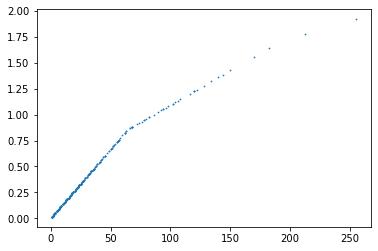

In [109]:
plt.scatter(test.iloc[0]["encoded_ipd"],test.iloc[0]["decoded_ipd"],s=0.5)

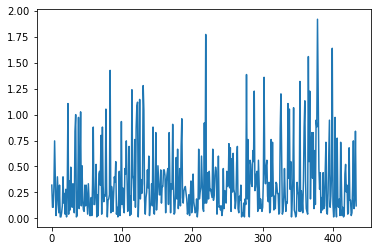

In [116]:
plt.plot(test.iloc[0]["decoded_ipd"])

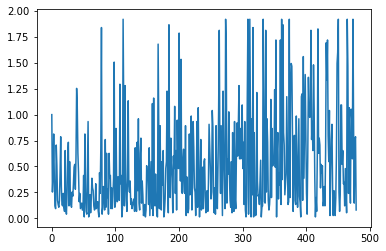

In [117]:
plt.plot(test.iloc[1]["decoded_ipd"])

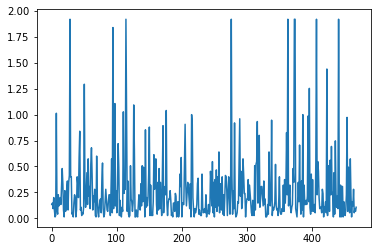

In [118]:
plt.plot(test.iloc[20]["decoded_ipd"])

In [120]:
test["lenseq"] = [len(x) for x in test["sequence"]]

In [121]:
test

,alignment_flag,scaffold,start,CIGAR_string,HoleID,sequence,encoded_ipd,decoded_ipd,lenseq
0,4,*,0,*,21365366,AATGTCAGAGCCAGTCCTTCACCGCGGACGGATTACGTGCAACGCA...,"[24, 8, 8, 22, 56, 29, 2, 10, 30, 17, 4, 24, 1...","[0.32, 0.10666666666666667, 0.1066666666666666...",434
1,4,*,0,*,21365366,CATTAAATAAATAAAAACCACTACTCGATGTGAAATAAATCAAATT...,"[86, 19, 32, 61, 28, 9, 7, 53, 38, 13, 10, 8, ...","[1.0, 0.25333333333333335, 0.4266666666666667,...",479
2,4,*,0,*,21365366,CGCTCATAGCGAGGTTATCAATTTCAGTGGCGAATGTCAGCGCCAG...,"[30, 26, 29, 14, 13, 19, 26, 63, 46, 53, 3, 63...","[0.4, 0.3466666666666667, 0.38666666666666666,...",476
3,4,*,0,*,21365366,CATTAAATAAATAAAAACAATAACGCTATTGAAATAAATCAAAGTC...,"[2, 5, 142, 30, 4, 17, 3, 30, 1, 15, 19, 12, 2...","[0.02666666666666667, 0.06666666666666667, 1.3...",483
4,4,*,0,*,21365366,CGCTCATAGGCGAGGTTTATCAATTCAGTGGCTAATGTCCAGCGCC...,"[40, 1, 3, 23, 13, 14, 82, 176, 13, 17, 21, 24...","[0.5333333333333333, 0.013333333333333334, 0.0...",481
...,...,...,...,...,...,...,...,...,...
113,4,*,0,*,30933379,ATTATTATTGCGATGGGAGGTTTAGCATGCGGTGCGGCTGGTGATT...,"[14, 4, 41, 32, 14, 6, 44, 17, 47, 82, 7, 4, 2...","[0.18666666666666668, 0.05333333333333334, 0.5...",472
114,4,*,0,*,30933379,GTTCCCACACGGGATGATTAACGTTATCCGGCGCATAAACCGGAAA...,"[45, 14, 40, 37, 92, 11, 120, 21, 68, 236, 10,...","[0.6, 0.18666666666666668, 0.5333333333333333,...",446
115,4,*,0,*,30933379,ATTATTTCGATTGGCGGTTTTCTACCTTGACGGTGCTTCTTGTGCG...,"[146, 61, 255, 49, 31, 14, 21, 154, 255, 19, 2...","[1.4, 0.8133333333333334, 1.92, 0.653333333333...",460
116,4,*,0,*,30933379,TTCCATTCAACGCCACAGCGGATATTAACGTTATCCGCGCATAACG...,"[60, 53, 50, 34, 15, 220, 8, 45, 20, 40, 2, 1,...","[0.8, 0.7066666666666667, 0.6666666666666666, ...",451
